# Wstęp do Sztucznej Inteligencji

Przed rozpoczęciem pracy z notatnikiem zmień jego nazwę zgodnie z wzorem: `NrAlbumu_Nazwisko_Imie_PoprzedniaNazwa`.

Przed wysłaniem notatnika upewnij się, że rozwiązałeś wszystkie zadania/ćwiczenia.

# Temat: Sztuczne Sieci Neuronowe - Lab 1 - Perceptron

## Sztuczna komórka nerwowa
Za pierwszy model sieci neuronowej uważa sie zainspirowany modelem biologicznym, model neuronu zaproponowany przez W. McCullacha i W. Pittsa w 1943 roku. Był to prosty neuron zdefiniowany jako układ z pewnym progiem wrażliwości posiadającym dwa typy wejść: pobudzające i hamujące. Założono, że układ ten może przyjmować tylko dwa stany: aktywny bądź nieaktywny.
![neuron.png](../images/neuronl.png)

Model neuronu McCullacha-Pittsa przedstawiony na powyższym rysunku, można opisać zależnością
$$y = f\left(\sum\limits_{i=1}^N{w_ix_i}+w_0\right)$$
gdzie:

- funkcja $f(\cdot)$ jest funkcją aktywacji neuronu,
- wartości $x_i$ są sygnałami wejściowymi,
- współczynniki $w_i$ są wagami połączeń synaptycznych,
- współczynnik $w_0$ jest progiem wrażliwości neuronu (tzw. biasem).

W oryginalnym modelu McCullocha-Pittsa jako funkcji aktywacji użyto funkcji skokowej, a dokładniej pseudofunkcji Heaviside’a
$$ f(u) = \left\{\begin{array}{l}
1, \quad u \geq 0,\\
0, \quad u<0.\end{array}\right.$$

## Perceptron
Model neuronu McCullacha-Pittsa opisany powyżej z odpowiednio dobraną strategią uczenia nazywany jest _perceptronem Rosenblatta_ lub krótko _perceptronem_.

Niech wektory sygnałów wejściowych oraz wartości wag będą odpowiednio postaci $x = [1, x_1, x_2, \ldots, x_N]$ oraz
$w = [w_0, w_1, \ldots, w_N]$. Do wektora $x$ dołączono składową zerową $x_0 = 1$, stanowiącą sygnał polaryzacji, natomiast wartość wagi $w_0$ jest progiem wrażliwości neuronu (biasem). 

Wówczas model perceptronu możemy zapisać w postaci
$$y = f(u) = f\left(\sum\limits_{i=0}^N{w_ix_i}\right)$$

### Zastosowania prerceprtronu
Perceptron na wyjściu zgodnie z funkcją aktywacji może przyjmować tylko dwie wartości 0 lub 1, wobec tego może on zostać wykorzystany do klasyfikacji wzorców pochodzących z dwóch różnych klas. Jeśli wartość sumatora jest dodatnia to wzorzec zostanie zaklasyfikowany do klasy 1, w przeciwnym przypadku będzie to klasa 0.

Rozważmy problem w przestrzeni dwuwymiarowej ($N = 2$), wówczas perceptron odseparowuje klasy od siebie za pomocą linii prostej (w dowolnym wymiarze jest to ($N − 1$)-wymiarowa hiperpłaszczyzna) danej równaniem
$$w_0x_0+w_1x_1+w_2x_2=0,$$
co można zapisać w postaci równania kierunkowego prostej
$$x_2=-\frac{w_1}{w_2}x_1-\frac{w_0}{w_2}.$$
Na poniższym rysunku przedstawiona jest interpretacja geometryczna działania perceptronu w przypadku dwuwymiarowym, widzimy, że wagi sygnałów wejściowych wyznaczają nachylenie prostej, natomiast bias odpowiedzialny jest za przesunięcie prostej.
![perc2d.png](../images/perc2d.png)

### Uczenie perceptronu
Uczenie perceptronu należy do grupy uczenia z nauczycielem i polega na takim doborze wektora wag $w$, aby sygnały wyjściowe neuronu $y$ były najbliżej wartości pożądanej $d$. Najpopularniejszą metodą uczenia perceptronu jest tzw. _reguła perceptronu_, którą można opisać w postaci kilku kroków.

Załóżmy, że dysponujemy zbiorem wektorów uczących postaci $\{x^{(0)}, x^{(1)}, \ldots, x^{(P)}\}$ oraz odpowiadającym mu zbiorem wartości pożądanych $\{d^{(0)}, d^{(1)},\ldots, d^{(P)}\}$.

#### Reguła perceptronu
1. Ustalamy $t = 0$.
2. Ustalamy w sposób losowy początkowe wartości wektora wag $w$.
3. Prezentujemy na wejścia perceptronu wektor uczący $x^{(t)}$.
4. Obliczamy odpowiedź perceptronu $y$ zgodnie z wzorem $y = f\left(\sum\limits_{i=0}^N{w_ix^{(t)}_i}\right)$
5. Porównujemy odpowiedź perceptronu $y$ z pożądaną odpowiedzią $d^{(t)}$.
6. Modyfikujemy wartości wag według poniższych reguł, parametr $\eta\in(0,1)$ to _współczynnuk uczenia_:
   - jeśli $y = d^{(t)}$ to wagi pozostają niezmienione,
   - jeśli $y = 0$, a $d^{(t)}=1$ to $w_i = w_i + \eta x_i^{(t)}$,
   - jeśli $y = 1$, a $d^{(t)}=0$ to $w_i = w_i - \eta x_i^{(t)}$.
7. Jeżeli warunek zatrzymania nie jest spełniony, to ustalamy $t = t + 1$ i wracamy do kroku 3, w przeciwnym przypadku kończymy algorytm.

Wykonanie powyższej procedury dla wszystkich wektorów uczących nazywamy _epoką uczenia_. W przypadku uczenia perceptronu wykonujemy tyle epok, aż wszystkie przykłady uczące będą dobrze sklasyfikowane lub błąd klasyfikacji będzie dostatecznie mały. Stabilność oraz szybkość uczenia tym algorytmem w istotny sposób zależy od doboru
parametru $\eta$. Współczynnik ten dobierany jest najczęściej w sposób empiryczny.

Przykładowy przebieg uczenia dla danych `2D.csv`:
![anim_perc.gif](../images/anim_perc.gif)

## Zadanie 1
Zaimplementuj model preceptronu w postaci klasy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Praktyczny copy paste z repo Tensor
class Perceptron:
	def __init__(self, n):
		self.w = np.random.uniform(-1.0, 1.0, n + 1)

	def _with_bias(self, x):
		x = np.asarray(x, dtype=float).ravel()
		if len(x) == len(self.w) - 1:
			return np.r_[1.0, x]
		if len(x) == len(self.w):
			return x
		raise ValueError(f"Invalid input vector size: {len(x)}")

	def predict(self, x):
		x = self._with_bias(x)
		return 1 if np.dot(self.w, x) >= 0 else 0

	def train(self, xx, d, eta, tol):
		xx = np.asarray(xx, dtype=float)
		d = np.asarray(d, dtype=int).ravel()

		history = []
		max_epochs = 10000

		for _ in range(max_epochs):
			idx = np.random.permutation(len(xx))
			mistakes = 0

			for i in idx:
				x = np.r_[1.0, xx[i]]
				y = 1 if np.dot(self.w, x) >= 0 else 0
				e = d[i] - y

				if e != 0:
					self.w += eta * e * x
					mistakes += 1

			err = mistakes / len(xx)
			history.append(err)

			if err <= tol:
				break

		return history

	def evaluate_test(self, xx, d):
		xx = np.asarray(xx, dtype=float)
		d = np.asarray(d, dtype=int).ravel()

		y = np.array([self.predict(x) for x in xx], dtype=int)
		err = np.mean(y != d)
		return err, y

## Zadanie 2
- Stwórz dwa obiekty klasy `Perceptron`. 
- Wczytaj dane z plików `2D.csv` oraz `3D.csv.`
- Pierwszy z perceptronów naucz klasyfikować dane z pliku `2D.csv`, ucz tylko na losowej części danych (np. 80%)
- Drugi z perceptronów naucz klasyfikować dane z pliku `3D.csv`, ucz tylko na losowej części danych (np. 80%)
- Oba zbiory danych są przykładami problemów liniowo separowalnych, a więc należy uczyć modele tak aby uzyskiwać dla danych uczących błąd równy zero.
- Przedstaw rezultaty uczenia na wykresach, odpowiednio 2D lub 3D. Na wykresach powinny znaleźć się dane testowe, tzn. te które nie były wykorzystywane w trakcie uczenia oraz linia (płaszczyzna) rozdzielająca klasy.

2D - błąd treningowy: 0.0
2D - błąd testowy: 0.0
3D - błąd treningowy: 0.0
3D - błąd testowy: 0.0


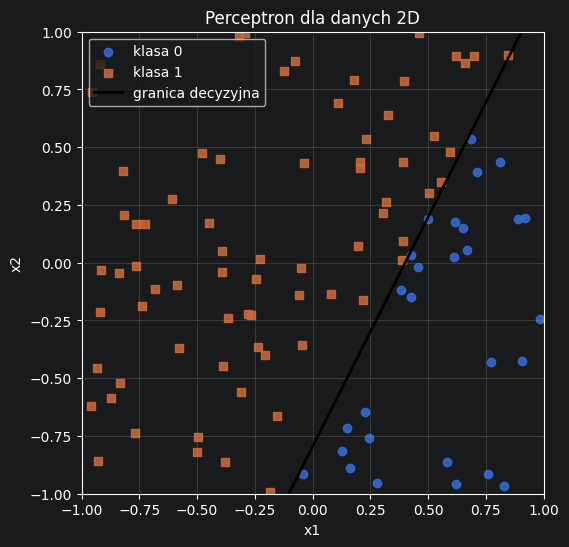

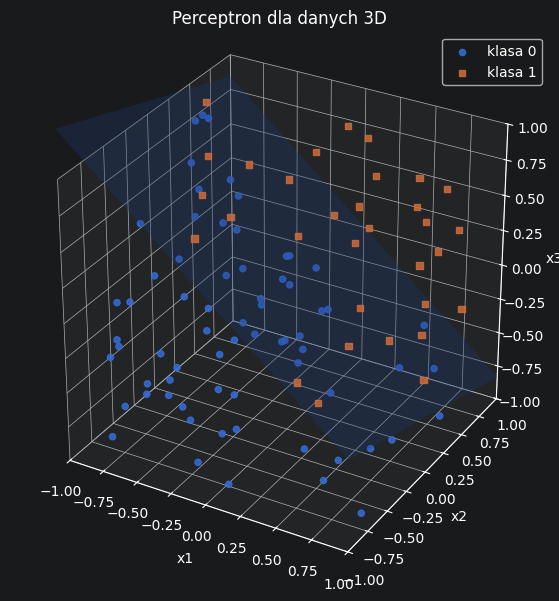

In [7]:
def load_dataset(path):
	df = pd.read_csv(
		path,
		sep=";",
		header=None,
		engine="python",
		decimal=",",
		on_bad_lines="skip"
	)

	df = df.apply(pd.to_numeric, errors="coerce").dropna(how="any").reset_index(drop=True)

	if df.empty:
		raise ValueError(f"Could not load file: {path}")

	data = df.to_numpy(dtype=float)

	if data.shape[1] < 2:
		raise ValueError(f"Too few columns: {path}")

	X = data[:, :-1]
	y = data[:, -1].astype(int)

	classes = np.unique(y)
	if len(classes) != 2:
		raise ValueError(f"File {path} does not contain exactly 2 classes.")

	if not np.array_equal(np.sort(classes), np.array([0, 1])):
		mapping = {classes[0]: 0, classes[1]: 1}
		y = np.array([mapping[v] for v in y], dtype=int)

	return X, y


def split_train_test(X, y, train_ratio=0.8, seed=42):
	rng = np.random.default_rng(seed)
	idx = rng.permutation(len(X))
	cut = int(train_ratio * len(X))
	train_idx, test_idx = idx[:cut], idx[cut:]
	return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def plot_2d(perceptron, X_test, y_test, title):
	plt.figure(figsize=(8, 6))

	for cls, marker, label in [
		(0, "o", "klasa 0"),
		(1, "s", "klasa 1"),
	]:
		pts = X_test[y_test == cls]
		if len(pts):
			plt.scatter(pts[:, 0], pts[:, 1], marker=marker, label=label, alpha=0.85)

	w = perceptron.w
	xs = np.linspace(-1, 1, 300)

	if abs(w[2]) > 1e-12:
		ys = -(w[0] + w[1] * xs) / w[2]
		plt.plot(xs, ys, "k-", linewidth=2, label="granica decyzyjna")
	elif abs(w[1]) > 1e-12:
		x0 = -w[0] / w[1]
		plt.axvline(x0, color="k", linewidth=2, label="granica decyzyjna")

	plt.xlim(-1, 1)
	plt.ylim(-1, 1)
	plt.gca().set_aspect("equal", adjustable="box")
	plt.title(title)
	plt.xlabel("x1")
	plt.ylabel("x2")
	plt.legend()
	plt.grid(True, alpha=0.3)
	plt.show()


def plot_3d(perceptron, X_test, y_test, title):
	fig = plt.figure(figsize=(9, 7))
	ax = fig.add_subplot(111, projection="3d")

	for cls, marker, label in [
		(0, "o", "klasa 0"),
		(1, "s", "klasa 1"),
	]:
		pts = X_test[y_test == cls]
		if len(pts):
			ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], marker=marker, label=label, alpha=0.85)

	w = perceptron.w
	xx, yy = np.meshgrid(np.linspace(-1, 1, 30), np.linspace(-1, 1, 30))

	if abs(w[3]) > 1e-12:
		zz = -(w[0] + w[1] * xx + w[2] * yy) / w[3]
		ax.plot_surface(xx, yy, zz, alpha=0.3, edgecolor="none")

	ax.set_xlim(-1, 1)
	ax.set_ylim(-1, 1)
	ax.set_zlim(-1, 1)
	ax.set_box_aspect((1, 1, 1))
	ax.set_title(title)
	ax.set_xlabel("x1")
	ax.set_ylabel("x2")
	ax.set_zlabel("x3")
	ax.legend()
	plt.show()


X2, y2 = load_dataset("2D.csv")
X3, y3 = load_dataset("3D.csv")

X2_train, X2_test, y2_train, y2_test = split_train_test(X2, y2, train_ratio=0.8, seed=42)
X3_train, X3_test, y3_train, y3_test = split_train_test(X3, y3, train_ratio=0.8, seed=42)

p2 = Perceptron(X2_train.shape[1])
p3 = Perceptron(X3_train.shape[1])

hist2 = p2.train(X2_train, y2_train, eta=0.1, tol=0.0)
hist3 = p3.train(X3_train, y3_train, eta=0.1, tol=0.0)

err2_train, _ = p2.evaluate_test(X2_train, y2_train)
err2_test, _ = p2.evaluate_test(X2_test, y2_test)

err3_train, _ = p3.evaluate_test(X3_train, y3_train)
err3_test, _ = p3.evaluate_test(X3_test, y3_test)

print("2D - błąd treningowy:", err2_train)
print("2D - błąd testowy:", err2_test)
print("3D - błąd treningowy:", err3_train)
print("3D - błąd testowy:", err3_test)

plot_2d(p2, X2_test, y2_test, "Perceptron dla danych 2D")
plot_3d(p3, X3_test, y3_test, "Perceptron dla danych 3D")

&copy; Cracow University of Technology